In [2]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt

import main as lightcode
import hardware as hw
import graph_transformations as gt
import stacked_graph as sg
import input_validation as validate
import data_collection as dc
import code_generation as cg
import models
import numpy as np


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
CPU_MAX_CLOCK = 5.0875 * 10**9  # 5.0875 e+9 5Ghz
CPU_AVERAGE_CLOCK = 3.208 * 10**9  # 60**9, 6
PHU_MIN_CLOCK = 9.7 * 10**9  # 100**9, 10 Ghz
GPU_FP32_CLOCK = 1.98 * 10**9 #1.98 GHz


GPC = 8                         # Graphical Processing Clusters
TPC_per_GPC = 9                 # Texture Processing Clusters/Graphical Processing Cluster
SM_per_TPC = 2                  # Streaming multiprocessors / Texture Processing Cluster
fp32_CUDA_cores_per_SM = 128    # fp32_CUDA_cores / Streaming multiprocessor
TC_per_SM = 4                   # Tensor Cores / Streaming multiprocessor

sequence_lengths = []
gpu = []
gpu_phu_1 = []
gpu_phu_2 = []
gpu_phu_5 = []
gpu_phu_10 = []
gpu_phu_15 = []
gpu_phu_20 = []


model = models.llama_prefill

iterations = 20
start, stop = 0, 60000

for i in range(iterations):
    length = int(np.exp(i / (iterations - 1) * np.log(stop)))
    sequence_lengths.append(length)

    # gpu
    optimization = 'time'
    hardware = []
    hw.Hardware._hardware_reset()
    hardware.append(hw.GPU(GPU_FP32_CLOCK, GPC, TPC_per_GPC, SM_per_TPC, fp32_CUDA_cores_per_SM, TC_per_SM))
    available_hardware = hw.initilize_hardware(hardware)

    ans = lightcode.graph_search(
        models.llama_prefill,
        optimization,
        available_hardware,
        moc_sequence_length = length,
        profiles=True,
        data_collection=True,
    )
    gpu.append(ans['Makespan'])


    optimization = 'always_phu'
    # gpu_phu_1
    hardware = []
    hw.Hardware._hardware_reset()
    hardware.append(hw.PHU(PHU_MIN_CLOCK, 1, 20))
    hardware.append(hw.GPU(GPU_FP32_CLOCK, GPC, TPC_per_GPC, SM_per_TPC, fp32_CUDA_cores_per_SM, TC_per_SM))
    available_hardware = hw.initilize_hardware(hardware)

    ans = lightcode.graph_search(
        models.llama_prefill,
        optimization,
        available_hardware,
        moc_sequence_length = length,
        profiles=True,
        data_collection=True,
    )
    gpu_phu_1.append(ans['Makespan'])


    # gpu_phu_2
    hardware = []
    hw.Hardware._hardware_reset()
    hardware.append(hw.PHU(PHU_MIN_CLOCK, 2, 20))
    hardware.append(hw.GPU(GPU_FP32_CLOCK, GPC, TPC_per_GPC, SM_per_TPC, fp32_CUDA_cores_per_SM, TC_per_SM))
    available_hardware = hw.initilize_hardware(hardware)

    ans = lightcode.graph_search(
        models.llama_prefill,
        optimization,
        available_hardware,
        moc_sequence_length = length,
        profiles=True,
        data_collection=True,
    )
    gpu_phu_2.append(ans['Makespan'])

    # gpu_phu_5
    hardware = []
    hw.Hardware._hardware_reset()
    hardware.append(hw.PHU(PHU_MIN_CLOCK, 5, 20))
    hardware.append(hw.GPU(GPU_FP32_CLOCK, GPC, TPC_per_GPC, SM_per_TPC, fp32_CUDA_cores_per_SM, TC_per_SM))
    available_hardware = hw.initilize_hardware(hardware)

    ans = lightcode.graph_search(
        models.llama_prefill,
        optimization,
        available_hardware,
        moc_sequence_length = length,
        profiles=True,
        data_collection=True,
    )
    gpu_phu_5.append(ans['Makespan'])

    # gpu_phu_10
    hardware = []
    hw.Hardware._hardware_reset()
    hardware.append(hw.PHU(PHU_MIN_CLOCK, 10, 20))
    hardware.append(hw.GPU(GPU_FP32_CLOCK, GPC, TPC_per_GPC, SM_per_TPC, fp32_CUDA_cores_per_SM, TC_per_SM))
    available_hardware = hw.initilize_hardware(hardware)

    ans = lightcode.graph_search(
        models.llama_prefill,
        optimization,
        available_hardware,
        moc_sequence_length = length,
        profiles=True,
        data_collection=True,
    )
    gpu_phu_10.append(ans['Makespan'])

    # gpu_phu_15
    hardware = []
    hw.Hardware._hardware_reset()
    hardware.append(hw.PHU(PHU_MIN_CLOCK, 15, 20))
    hardware.append(hw.GPU(GPU_FP32_CLOCK, GPC, TPC_per_GPC, SM_per_TPC, fp32_CUDA_cores_per_SM, TC_per_SM))
    available_hardware = hw.initilize_hardware(hardware)

    ans = lightcode.graph_search(
        models.llama_prefill,
        optimization,
        available_hardware,
        moc_sequence_length = length,
        profiles=True,
        data_collection=True,
    )
    gpu_phu_15.append(ans['Makespan'])

    # gpu_phu_20
    hardware = []
    hw.Hardware._hardware_reset()
    hardware.append(hw.PHU(PHU_MIN_CLOCK, 20, 20))
    hardware.append(hw.GPU(GPU_FP32_CLOCK, GPC, TPC_per_GPC, SM_per_TPC, fp32_CUDA_cores_per_SM, TC_per_SM))
    available_hardware = hw.initilize_hardware(hardware)

    ans = lightcode.graph_search(
        models.llama_prefill,
        optimization,
        available_hardware,
        moc_sequence_length = length,
        profiles=True,
        data_collection=True,
    )
    gpu_phu_20.append(ans['Makespan'])

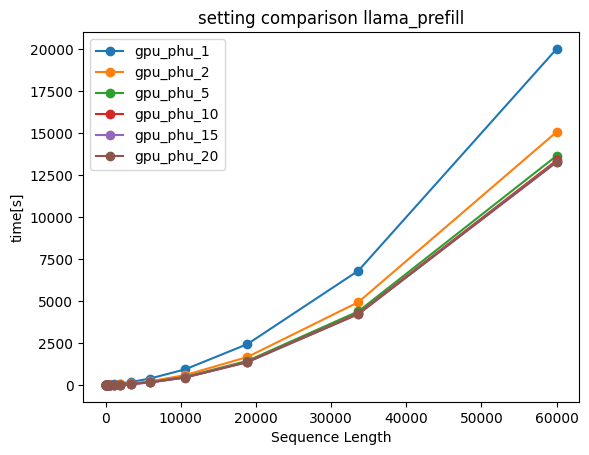

In [38]:
# plt.plot(sequence_lengths, gpu, marker='o', label='gpu')
plt.plot(sequence_lengths, gpu_phu_1, marker='o', label='gpu_phu_1')
plt.plot(sequence_lengths, gpu_phu_2, marker='o', label='gpu_phu_2')
plt.plot(sequence_lengths, gpu_phu_5, marker='o', label='gpu_phu_5')
plt.plot(sequence_lengths, gpu_phu_10, marker='o', label='gpu_phu_10')
plt.plot(sequence_lengths, gpu_phu_15, marker='o', label='gpu_phu_15')
plt.plot(sequence_lengths, gpu_phu_20, marker='o', label='gpu_phu_20')

plt.title(f'setting comparison llama_prefill')
plt.xlabel('Sequence Length')
plt.ylabel('time[s]')

# plt.xscale("log")
# plt.yscale("log")


plt.legend()
plt.show()

In [37]:
print(gpu[0])
print(gpu_phu_10[0])
print(gpu_phu_20[0])

print(gpu[19])
print(gpu_phu_10[19])
print(gpu_phu_20[19])

0.00238
0.00454
0.00349
13185.42837
13366.66914
13258.78113
